In [6]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [4]:
# define state
class BMI_State(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float

In [5]:
def cal_bmi(state: BMI_State) -> BMI_State:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2) # roung ki value upto 2 decimal places
    return state

In [7]:
# Create Graph
graph = StateGraph(BMI_State)

# Add the Nodes
graph.add_node('Claculate_BMI', cal_bmi)

# Add the edges
graph.add_edge(START,'Claculate_BMI')
graph.add_edge('Claculate_BMI',END)

# Compile the graph
workflow = graph.compile()

In [8]:
# Execute the Graph
initial_state = {'weight_kg': 80, "height_m":1.73}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73}


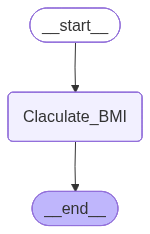

In [10]:
# Visualize the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

# Labeled BMI

In [11]:
# define state
class BMI_State2(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    label : str

In [12]:
def cal_bmi(state: BMI_State2) -> BMI_State2:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2) # roung ki value upto 2 decimal places
    return state

In [13]:
def label_bmi(state: BMI_State2) -> BMI_State2:
    bmi = state['bmi']

    if bmi < 18.5:
        state['label'] = "UnderWeight"
    elif 18.5 <= bmi < 25 :
        state['label'] = "Normal"
    elif 25 <= bmi < 30 :
        state['label'] = "OverWeight"
    else:
        state['label'] = "Obese" 
    
    return state
    


In [19]:
# Create Graph
graph = StateGraph(BMI_State2)

# Add the Nodes
graph.add_node('Claculate_BMI', cal_bmi)
graph.add_node('label_bmi', label_bmi)

# Add the edges
graph.add_edge(START,'Claculate_BMI')
graph.add_edge('Claculate_BMI','label_bmi')
graph.add_edge('label_bmi',END)

# Compile the graph
workflow2 = graph.compile()

In [20]:
# Execute the Graph
initial_state = {'weight_kg': 80, "height_m":1.73}

final_state = workflow2.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'label': 'OverWeight'}


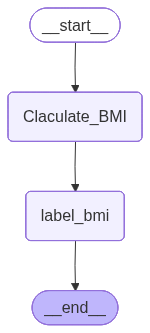

In [18]:
# Visualize the graph 
from IPython.display import Image
Image(workflow2.get_graph().draw_mermaid_png())